# **FYP Stock Level Classifcation**

**Import Module**

All the import module will be written below

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils import resample
from sklearn.linear_model import SGDClassifier
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV
import joblib
import seaborn as sns
from xgboost import plot_importance

**Prepare Historical Training Data**

In [2]:
order_df = pd.read_csv("Order Data.csv")
order_item_df = pd.read_csv("Order Items Data.csv")
product_df = pd.read_csv("Product Data.csv")

Drop Incorrect Status

In [3]:
order_df = order_df[order_df['order_status'] == 'delivered'].drop(['order_status'], axis=1)

Merge and Setup Time

In [4]:
data = order_item_df.merge(order_df, on='order_id')

In [5]:
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
data['month'] = data['order_purchase_timestamp'].dt.to_period('M')

Calculate Monthly Sales per Product

In [6]:
monthly_sales = data.groupby(['product_id', 'month']).size().reset_index(name='actual_demand')

In [7]:
pivot = monthly_sales.pivot(index='product_id', columns='month', values='actual_demand').fillna(0)
df_history = pivot.stack().reset_index(name='actual_demand')

Feature Engineering for Predicted Demand (The "Naive" Proxy)

In [8]:
df_history['predicted_monthly_demand'] = df_history.groupby('product_id')['actual_demand'].shift(1)

In [9]:
df_history['actual_future_sales'] = df_history.groupby('product_id')['actual_demand'].shift(-1)

In [10]:
df_train_clf = df_history.dropna()

Merge Static Features

In [11]:
df_train_clf = df_train_clf.merge(product_df[['product_id', 'quantity']], on='product_id', how='inner')

In [12]:
avg_price = order_item_df.groupby('product_id')['price'].mean().reset_index()
df_train_clf = df_train_clf.merge(avg_price, on='product_id', how='left')
df_train_clf = df_train_clf.merge(product_df[['product_id', 'product_category_name']], on='product_id', how='left')

In [13]:
mask_active = (
    (df_train_clf['predicted_monthly_demand'] > 0) |  
    (df_train_clf['actual_demand'] > 0) |             
    (df_train_clf['actual_future_sales'] > 0)         
)

In [14]:
df_train_clean = df_train_clf[mask_active].copy()

Create Peak Season Feature

In [15]:
df_train_clean['month_number'] = df_train_clean['month'].dt.month

In [16]:
df_train_clean['is_peak_season'] = df_train_clean['month_number'].apply(
    lambda x: 1 if x in [11] else 0
)

Generate Labels (The Ground Truth)

In [17]:
def get_label(row):
    stock = row['quantity']
    real_future_demand = row['actual_future_sales']
    
    # Business Rules
    if stock < (real_future_demand * 1.2):
        return 'Understock'
    elif stock > (real_future_demand * 2.0):
        return 'Overstock'
    else:
        return 'Optimal'

In [18]:
df_train_clean['target_status'] = df_train_clean.apply(get_label, axis=1)

In [19]:
print(df_train_clean['target_status'].value_counts())

Overstock     102247
Understock     20504
Optimal        10768
Name: target_status, dtype: int64


In [20]:
category_cleanup = {
    'home_appliances_2': 'home_appliances',
    'home_comfort_2': 'home_comfort' 
}
df_train_clean['product_category_name'] = df_train_clean['product_category_name'].replace(category_cleanup)

Further Feature Enginnering

In [21]:
le_target = LabelEncoder()
df_train_clean['target_encoded'] = le_target.fit_transform(df_train_clean['target_status'])
joblib.dump(le_target, 'stock_level_classification_target_encoder.pkl')
le_target.classes_

array(['Optimal', 'Overstock', 'Understock'], dtype=object)

In [22]:
le_category = LabelEncoder()
df_train_clean['cat_encoded'] = le_category.fit_transform(df_train_clean['product_category_name'])
joblib.dump(le_category, 'stock_level_classification_category_encoder.pkl')

['stock_level_classification_category_encoder.pkl']

In [23]:
df_train_clean['weeks_of_supply'] = df_train_clean['quantity'] / ((df_train_clean['predicted_monthly_demand'] / 4.33) + 0.01)

In [24]:
features = ['quantity', 'predicted_monthly_demand','weeks_of_supply', 'is_peak_season', 'price', 'cat_encoded']

X = df_train_clean[features]
y = df_train_clean['target_encoded']

Data Splitting

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Resampling for Train Set

In [26]:
train_data = pd.concat([X_train, y_train], axis=1)

In [27]:
overstock = train_data[train_data['target_encoded'] == 1] 
understock = train_data[train_data['target_encoded'] == 2]
optimal = train_data[train_data['target_encoded'] == 0]

In [28]:
n_minority = len(understock)

In [29]:
overstock_multiplier = 3
n_overstock_target = n_minority * overstock_multiplier
overstock_down = resample(overstock, 
                          replace=False, 
                          n_samples=n_overstock_target,
                          random_state=42)
optimal_bal = resample(optimal, 
                       replace=True, 
                       n_samples=n_minority, 
                       random_state=42)
train_balanced = pd.concat([overstock_down, understock, optimal_bal])

In [30]:
X_train_bal = train_balanced[features]
y_train_bal = train_balanced['target_encoded']

### Model Training

Scale Data

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

**SVM**

In [53]:
svm_clf = SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001, random_state=42, n_jobs=-1, class_weight='balanced', early_stopping=True)

svm_clf.fit(X_train_scaled, y_train_bal)

y_pred = svm_clf.predict(X_test_scaled)

Model Evaluation (Accuracy, Precision, Recall, F1 Score)

Confusion Matrix:
+-----------------------+--------------------+----------------------+-----------------------+
|                       |   Pred Optimal (0) |   Pred Overstock (1) |   Pred Understock (2) |
+=======================+====================+======================+=======================+
| Actual Optimal (0)    |                891 |                 2088 |                   252 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Overstock (1)  |                871 |                25100 |                  4703 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Understock (2) |                281 |                  731 |                  5139 |
+-----------------------+--------------------+----------------------+-----------------------+


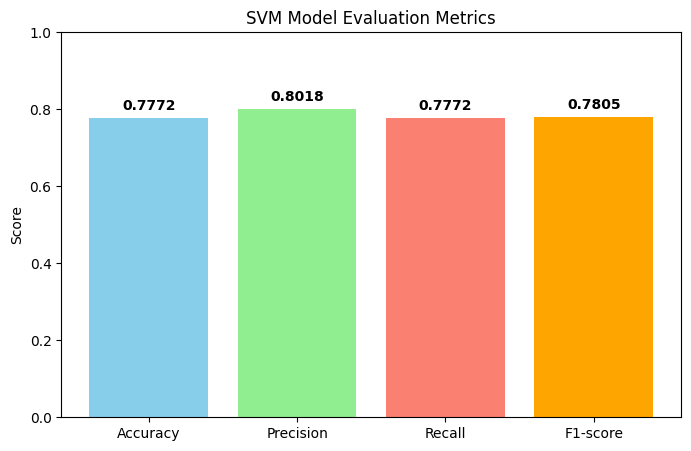

In [54]:
svm_cm = confusion_matrix(y_test, y_pred)
svm_accuracy = accuracy_score(y_test, y_pred)
svm_precision = precision_score(y_test, y_pred, average='weighted')
svm_recall = recall_score(y_test, y_pred, average='weighted')
svm_f1 = f1_score(y_test, y_pred, average='weighted')

class_names = ["Optimal (0)", "Overstock (1)", "Understock (2)"]

cm_table = [
    ["", f"Pred {class_names[0]}", f"Pred {class_names[1]}", f"Pred {class_names[2]}"],
    [f"Actual {class_names[0]}", svm_cm[0,0], svm_cm[0,1], svm_cm[0,2]],
    [f"Actual {class_names[1]}", svm_cm[1,0], svm_cm[1,1], svm_cm[1,2]],
    [f"Actual {class_names[2]}", svm_cm[2,0], svm_cm[2,1], svm_cm[2,2]]
]

print("Confusion Matrix:")
print(tabulate(cm_table, headers="firstrow", tablefmt="grid"))

# 4. Plot the Bar Chart (Same as before, just ensuring scores are correct)
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
scores = [svm_accuracy, svm_precision, svm_recall, svm_f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=['skyblue','lightgreen','salmon','orange'])
plt.ylim(0, 1) 
plt.title("SVM Model Evaluation Metrics")
plt.ylabel("Score")

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

**Random Forest**

In [270]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_clf.fit(X_train_bal, y_train_bal)

rf_y_pred = rf_clf.predict(X_test)

Model Evaluation (Accuracy, Precision, Recall, F1 Score)


Random Forest Confusion Matrix:
+-----------------------+--------------------+----------------------+-----------------------+
|                       |   Pred Optimal (0) |   Pred Overstock (1) |   Pred Understock (2) |
+=======================+====================+======================+=======================+
| Actual Optimal (0)    |               1556 |                 1513 |                   162 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Overstock (1)  |               3037 |                22534 |                  5103 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Understock (2) |                350 |                 1686 |                  4115 |
+-----------------------+--------------------+----------------------+-----------------------+


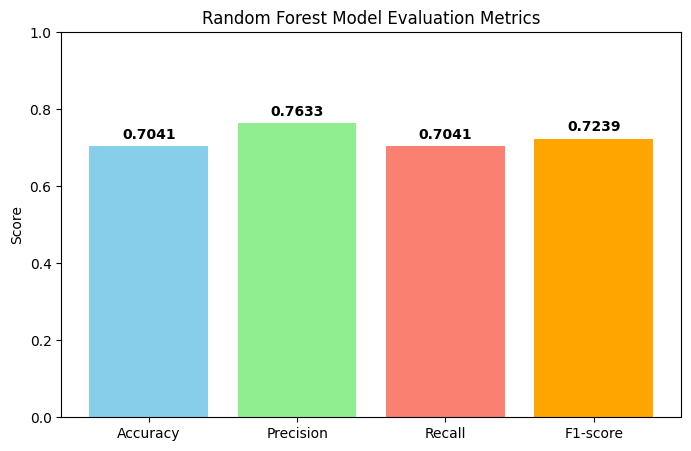

In [275]:
rf_cm = confusion_matrix(y_test, rf_y_pred)
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred, average='weighted')
rf_recall = recall_score(y_test, rf_y_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_y_pred, average='weighted')

class_names = ["Optimal (0)", "Overstock (1)", "Understock (2)"]

cm_table = [
    ["", f"Pred {class_names[0]}", f"Pred {class_names[1]}", f"Pred {class_names[2]}"],
    [f"Actual {class_names[0]}", rf_cm[0,0], rf_cm[0,1], rf_cm[0,2]],
    [f"Actual {class_names[1]}", rf_cm[1,0], rf_cm[1,1], rf_cm[1,2]],
    [f"Actual {class_names[2]}", rf_cm[2,0], rf_cm[2,1], rf_cm[2,2]]
]

print("\nRandom Forest Confusion Matrix:")
print(tabulate(cm_table, headers="firstrow", tablefmt="grid"))

# 5. Plot the Evaluation Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=['skyblue','lightgreen','salmon','orange'])
plt.ylim(0, 1) 
plt.title("Random Forest Model Evaluation Metrics")
plt.ylabel("Score")

# Add text labels on bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

**XGBoost**

In [31]:
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.3,
    max_depth=4,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

xgb_clf.fit(X_train_bal, y_train_bal)

xgb_y_pred = xgb_clf.predict(X_test)

Model Evaluation (Accuracy, Precision, Recall, F1 Score)


XGBoost Confusion Matrix:
+-----------------------+--------------------+----------------------+-----------------------+
|                       |   Pred Optimal (0) |   Pred Overstock (1) |   Pred Understock (2) |
+=======================+====================+======================+=======================+
| Actual Optimal (0)    |               1916 |                 1308 |                     7 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Overstock (1)  |               2165 |                23773 |                  4736 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Understock (2) |                601 |                  333 |                  5217 |
+-----------------------+--------------------+----------------------+-----------------------+


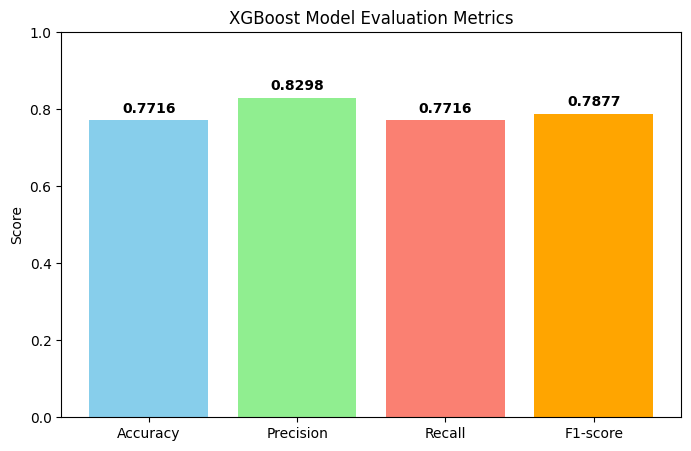

In [32]:
xgb_cm = confusion_matrix(y_test, xgb_y_pred)
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred, average='weighted')
xgb_recall = recall_score(y_test, xgb_y_pred, average='weighted')
xgb_f1 = f1_score(y_test, xgb_y_pred, average='weighted')

# 4. Create the 3x3 Confusion Matrix Table
class_names = ["Optimal (0)", "Overstock (1)", "Understock (2)"]

cm_table = [
    ["", f"Pred {class_names[0]}", f"Pred {class_names[1]}", f"Pred {class_names[2]}"],
    [f"Actual {class_names[0]}", xgb_cm[0,0], xgb_cm[0,1], xgb_cm[0,2]],
    [f"Actual {class_names[1]}", xgb_cm[1,0], xgb_cm[1,1], xgb_cm[1,2]],
    [f"Actual {class_names[2]}", xgb_cm[2,0], xgb_cm[2,1], xgb_cm[2,2]]
]

print("\nXGBoost Confusion Matrix:")
print(tabulate(cm_table, headers="firstrow", tablefmt="grid"))

# 5. Plot the Evaluation Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=['skyblue','lightgreen','salmon','orange'])
plt.ylim(0, 1) 
plt.title("XGBoost Model Evaluation Metrics")
plt.ylabel("Score")

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

### Hyperparameter Tuning

**SVM**

In [282]:
sgd = SGDClassifier(loss='hinge', random_state=42, n_jobs=-1, early_stopping=True)
svm_param = {
    'alpha': loguniform(1e-5, 1e-1),
    'penalty': ['l2', 'l1', 'elasticnet'],
    'learning_rate': ['optimal', 'adaptive'],
    'eta0': [0.01, 0.1, 1.0],
}

svm_random_search = RandomizedSearchCV(
    estimator=sgd,
    param_distributions=svm_param,
    n_iter=100,              
    scoring='f1_weighted',  
    cv=5,                   
    verbose=1,
    random_state=42,
    n_jobs=-1
)

svm_random_search.fit(X_train_scaled, y_train_bal)

print(f"\nBest Parameters: {svm_random_search.best_params_}")
print(f"Best CV Score: {svm_random_search.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters: {'alpha': 1.1811402095928174e-05, 'eta0': 0.1, 'learning_rate': 'optimal', 'penalty': 'elasticnet'}
Best CV Score: 0.6871


Model Evaluation (Accuracy, Precision, Recall, F1 Score)


SVM Confusion Matrix:
+-----------------------+--------------------+----------------------+-----------------------+
|                       |   Pred Optimal (0) |   Pred Overstock (1) |   Pred Understock (2) |
+=======================+====================+======================+=======================+
| Actual Optimal (0)    |                792 |                 2017 |                   422 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Overstock (1)  |               1139 |                24747 |                  4788 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Understock (2) |                332 |                  825 |                  4994 |
+-----------------------+--------------------+----------------------+-----------------------+


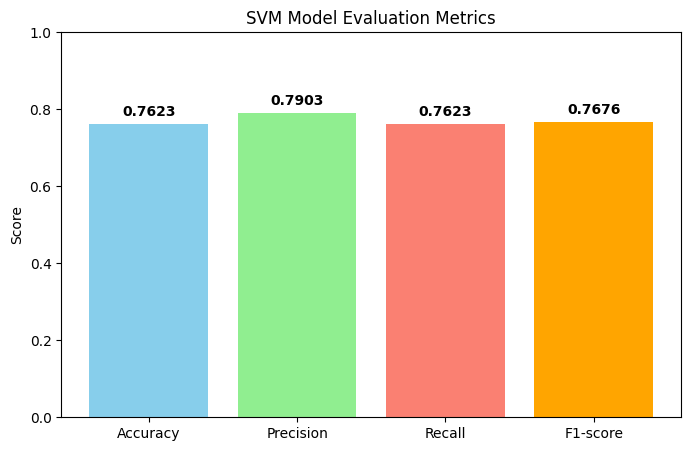

In [283]:
best_svm = svm_random_search.best_estimator_
best_svm_y_pred = best_svm.predict(X_test_scaled)

best_svm_cm = confusion_matrix(y_test, best_svm_y_pred)
best_svm_accuracy = accuracy_score(y_test, best_svm_y_pred)
best_svm_precision = precision_score(y_test, best_svm_y_pred, average='weighted')
best_svm_recall = recall_score(y_test, best_svm_y_pred, average='weighted')
best_svm_f1 = f1_score(y_test, best_svm_y_pred, average='weighted')

class_names = ["Optimal (0)", "Overstock (1)", "Understock (2)"]

cm_table = [
    ["", f"Pred {class_names[0]}", f"Pred {class_names[1]}", f"Pred {class_names[2]}"],
    [f"Actual {class_names[0]}", best_svm_cm[0,0], best_svm_cm[0,1], best_svm_cm[0,2]],
    [f"Actual {class_names[1]}", best_svm_cm[1,0], best_svm_cm[1,1], best_svm_cm[1,2]],
    [f"Actual {class_names[2]}", best_svm_cm[2,0], best_svm_cm[2,1], best_svm_cm[2,2]]
]

print("\nSVM Confusion Matrix:")
print(tabulate(cm_table, headers="firstrow", tablefmt="grid"))

# 5. Plot the Evaluation Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
scores = [best_svm_accuracy, best_svm_precision, best_svm_recall, best_svm_f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=['skyblue','lightgreen','salmon','orange'])
plt.ylim(0, 1) 
plt.title("SVM Model Evaluation Metrics")
plt.ylabel("Score")

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

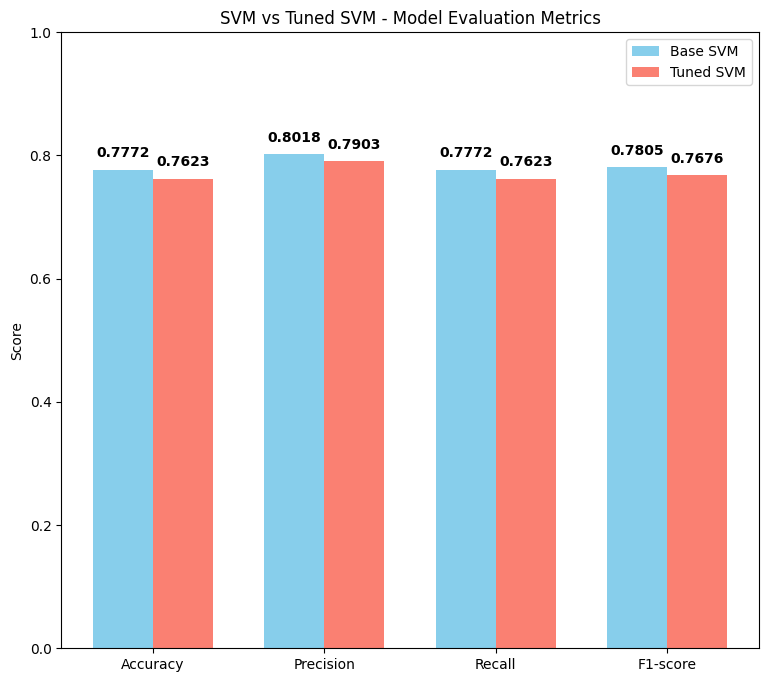

In [285]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
svm_scores = [svm_accuracy, svm_precision, svm_recall, svm_f1]
best_svm_scores = [best_svm_accuracy, best_svm_precision, best_svm_recall, best_svm_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,8))
plt.bar(x - width/2, svm_scores, width, label='Base SVM', color='skyblue')
plt.bar(x + width/2, best_svm_scores, width, label='Tuned SVM', color='salmon')

plt.ylim(0, 1)
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("SVM vs Tuned SVM - Model Evaluation Metrics")
plt.legend()

for i, v in enumerate(svm_scores):
    plt.text(i - width/2, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
for i, v in enumerate(best_svm_scores):
    plt.text(i + width/2, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

**Random Forest**

In [286]:
rf_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 40, 60],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42,class_weight='balanced',n_jobs=-1),
    param_distributions=rf_params,
    n_iter=100,              
    scoring='f1_weighted',  
    cv=5,                   
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_bal, y_train_bal)

print(f"\nBest Parameters: {rf_random_search.best_params_}")
print(f"Best CV Score: {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Score: 0.7805


Model Evaluation (Accuracy, Precision, Recall, F1 Score)


 Tuned Random Forest Confusion Matrix:
+-----------------------+--------------------+----------------------+-----------------------+
|                       |   Pred Optimal (0) |   Pred Overstock (1) |   Pred Understock (2) |
+=======================+====================+======================+=======================+
| Actual Optimal (0)    |               2062 |                 1080 |                    89 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Overstock (1)  |               3851 |                21847 |                  4976 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Understock (2) |                572 |                  315 |                  5264 |
+-----------------------+--------------------+----------------------+-----------------------+


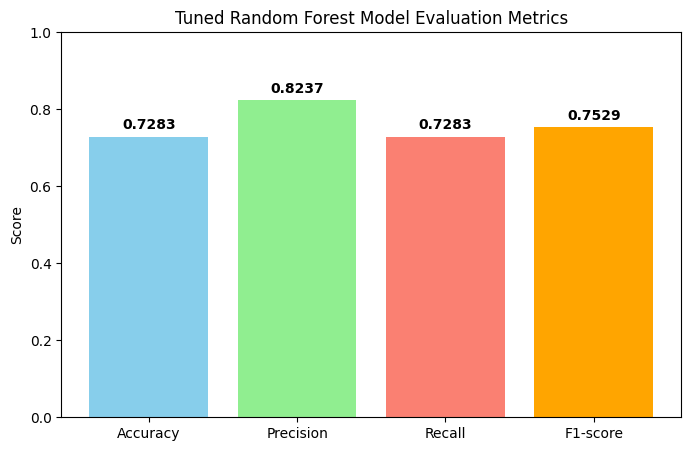

In [287]:
best_rf = rf_random_search.best_estimator_
best_rf_y_pred = best_rf.predict(X_test)

best_rf_cm = confusion_matrix(y_test, best_rf_y_pred)
best_rf_accuracy = accuracy_score(y_test, best_rf_y_pred)
best_rf_precision = precision_score(y_test, best_rf_y_pred, average='weighted')
best_rf_recall = recall_score(y_test, best_rf_y_pred, average='weighted')
best_rf_f1 = f1_score(y_test, best_rf_y_pred, average='weighted')

class_names = ["Optimal (0)", "Overstock (1)", "Understock (2)"]

cm_table = [
    ["", f"Pred {class_names[0]}", f"Pred {class_names[1]}", f"Pred {class_names[2]}"],
    [f"Actual {class_names[0]}", best_rf_cm[0,0], best_rf_cm[0,1], best_rf_cm[0,2]],
    [f"Actual {class_names[1]}", best_rf_cm[1,0], best_rf_cm[1,1], best_rf_cm[1,2]],
    [f"Actual {class_names[2]}", best_rf_cm[2,0], best_rf_cm[2,1], best_rf_cm[2,2]]
]

print("\n Tuned Random Forest Confusion Matrix:")
print(tabulate(cm_table, headers="firstrow", tablefmt="grid"))

# 5. Plot the Evaluation Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
scores = [best_rf_accuracy, best_rf_precision, best_rf_recall, best_rf_f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=['skyblue','lightgreen','salmon','orange'])
plt.ylim(0, 1) 
plt.title("Tuned Random Forest Model Evaluation Metrics")
plt.ylabel("Score")

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

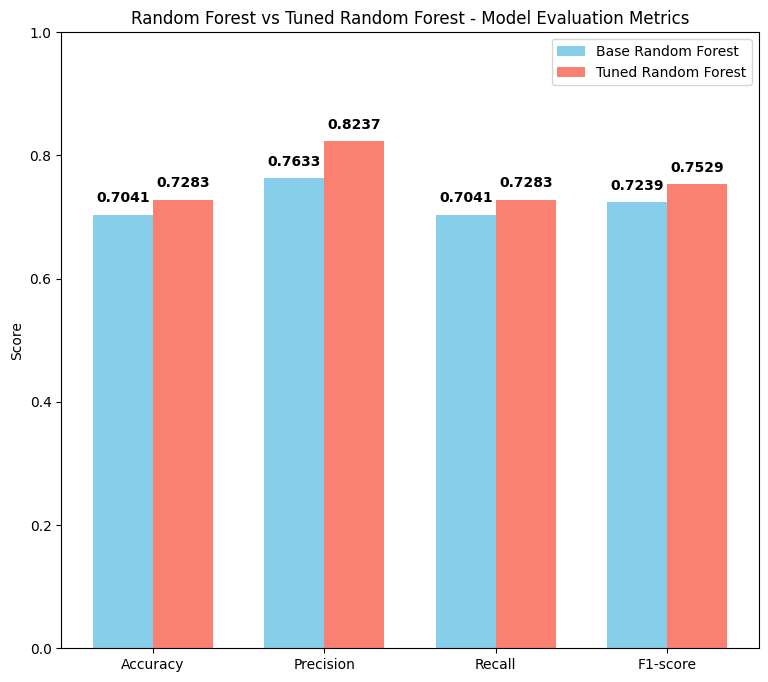

In [288]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]
best_rf_scores = [best_rf_accuracy, best_rf_precision, best_rf_recall, best_rf_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,8))
plt.bar(x - width/2, rf_scores, width, label='Base Random Forest', color='skyblue')
plt.bar(x + width/2, best_rf_scores, width, label='Tuned Random Forest', color='salmon')

plt.ylim(0, 1)
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Random Forest vs Tuned Random Forest - Model Evaluation Metrics")
plt.legend()

for i, v in enumerate(rf_scores):
    plt.text(i - width/2, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
for i, v in enumerate(best_rf_scores):
    plt.text(i + width/2, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

**XGBoost**

In [289]:
xgb_params = {
    'n_estimators': [300,500, 1000],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5, 1]
}
xgb_base = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=1 
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_params,
    n_iter=100,              
    scoring='f1_weighted',  
    cv=5,                   
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train_bal, y_train_bal)

print(f"\nBest Parameters: {xgb_random_search.best_params_}")
print(f"Best CV Score: {xgb_random_search.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.3, 'gamma': 0.5, 'colsample_bytree': 0.8}
Best CV Score: 0.7711


Model Evaluation (Accuracy, Precision, Recall, F1 Score)


 Tuned XGBoost Confusion Matrix:
+-----------------------+--------------------+----------------------+-----------------------+
|                       |   Pred Optimal (0) |   Pred Overstock (1) |   Pred Understock (2) |
+=======================+====================+======================+=======================+
| Actual Optimal (0)    |               1916 |                 1301 |                    14 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Overstock (1)  |               2430 |                23531 |                  4713 |
+-----------------------+--------------------+----------------------+-----------------------+
| Actual Understock (2) |                584 |                  420 |                  5147 |
+-----------------------+--------------------+----------------------+-----------------------+


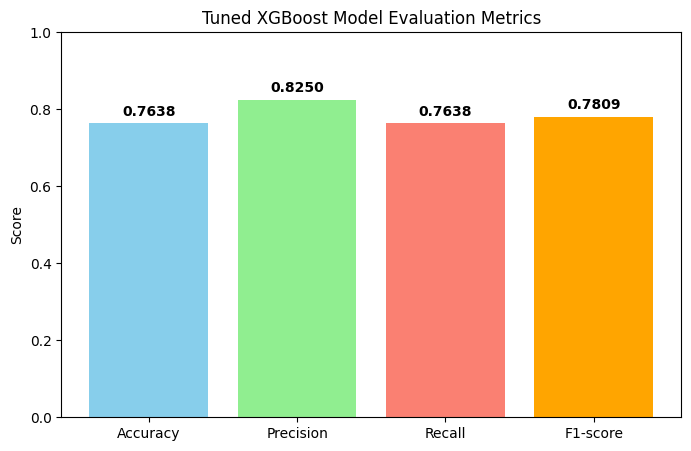

In [290]:
best_xgb = xgb_random_search.best_estimator_
best_xgb_y_pred = best_xgb.predict(X_test)

best_xgb_cm = confusion_matrix(y_test, best_xgb_y_pred)
best_xgb_accuracy = accuracy_score(y_test, best_xgb_y_pred)
best_xgb_precision = precision_score(y_test, best_xgb_y_pred, average='weighted')
best_xgb_recall = recall_score(y_test, best_xgb_y_pred, average='weighted')
best_xgb_f1 = f1_score(y_test, best_xgb_y_pred, average='weighted')

class_names = ["Optimal (0)", "Overstock (1)", "Understock (2)"]

cm_table = [
    ["", f"Pred {class_names[0]}", f"Pred {class_names[1]}", f"Pred {class_names[2]}"],
    [f"Actual {class_names[0]}", best_xgb_cm[0,0], best_xgb_cm[0,1], best_xgb_cm[0,2]],
    [f"Actual {class_names[1]}", best_xgb_cm[1,0], best_xgb_cm[1,1], best_xgb_cm[1,2]],
    [f"Actual {class_names[2]}", best_xgb_cm[2,0], best_xgb_cm[2,1], best_xgb_cm[2,2]]
]

print("\n Tuned XGBoost Confusion Matrix:")
print(tabulate(cm_table, headers="firstrow", tablefmt="grid"))

# 5. Plot the Evaluation Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
scores = [best_xgb_accuracy, best_xgb_precision, best_xgb_recall, best_xgb_f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color=['skyblue','lightgreen','salmon','orange'])
plt.ylim(0, 1) 
plt.title("Tuned XGBoost Model Evaluation Metrics")
plt.ylabel("Score")

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

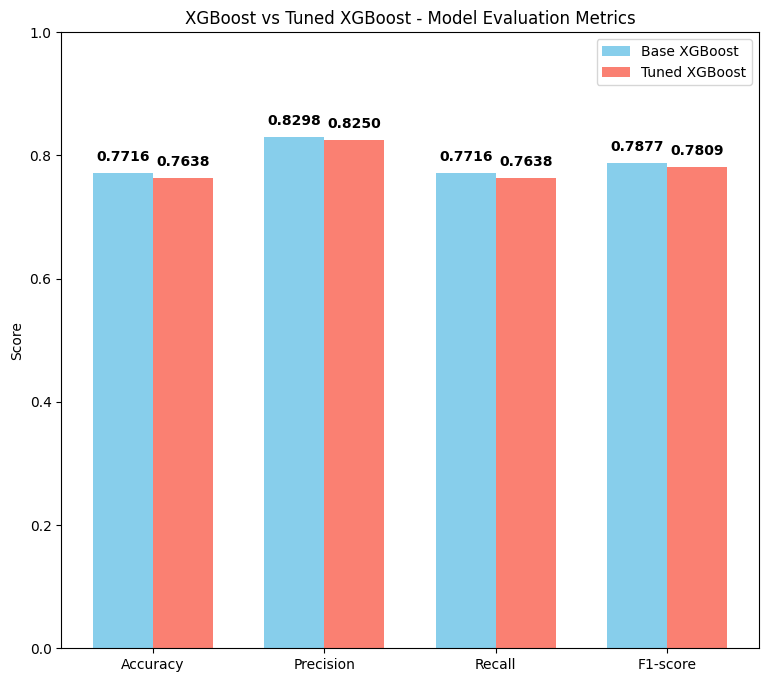

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]
best_xgb_scores = [best_xgb_accuracy, best_xgb_precision, best_xgb_recall, best_xgb_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,8))
plt.bar(x - width/2, xgb_scores, width, label='Base XGBoost', color='skyblue')
plt.bar(x + width/2, best_rf_scores, width, label='Tuned XGBoost', color='salmon')

plt.ylim(0, 1)
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("XGBoost vs Tuned XGBoost - Model Evaluation Metrics")
plt.legend()

for i, v in enumerate(xgb_scores):
    plt.text(i - width/2, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
for i, v in enumerate(best_xgb_scores):
    plt.text(i + width/2, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

**Best Model Performance Comparison Chart**

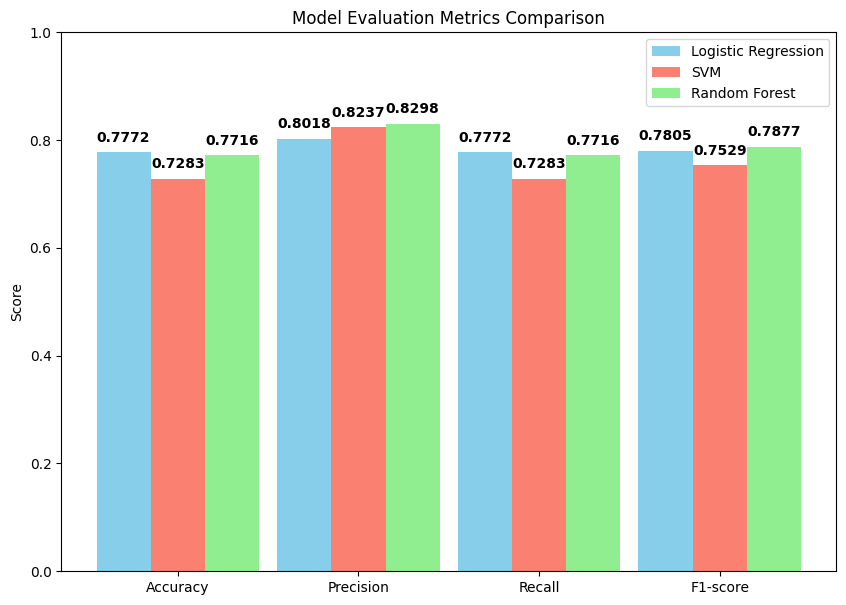

In [292]:
svm_scores = [svm_accuracy, svm_precision, svm_recall, svm_f1]
rf_scores = [best_rf_accuracy, best_rf_precision, best_rf_recall, best_rf_f1]
xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))   # positions
width = 0.3                  # bar width

plt.figure(figsize=(10,7))

# Plot bars
plt.bar(x - width, svm_scores, width, label="Logistic Regression", color="skyblue")
plt.bar(x, rf_scores, width, label="SVM", color="salmon")
plt.bar(x + width, xgb_scores, width, label="Random Forest", color="lightgreen")

plt.ylim(0, 1)
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Evaluation Metrics Comparison")
plt.legend()

# Add score labels
for i, scores in enumerate([svm_scores, rf_scores, xgb_scores]):
    offset = (-width if i==0 else width if i==2 else 0)
    for j, v in enumerate(scores):
        plt.text(j + offset, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

**Feature Importance for Best Model**

<Figure size 1000x600 with 0 Axes>

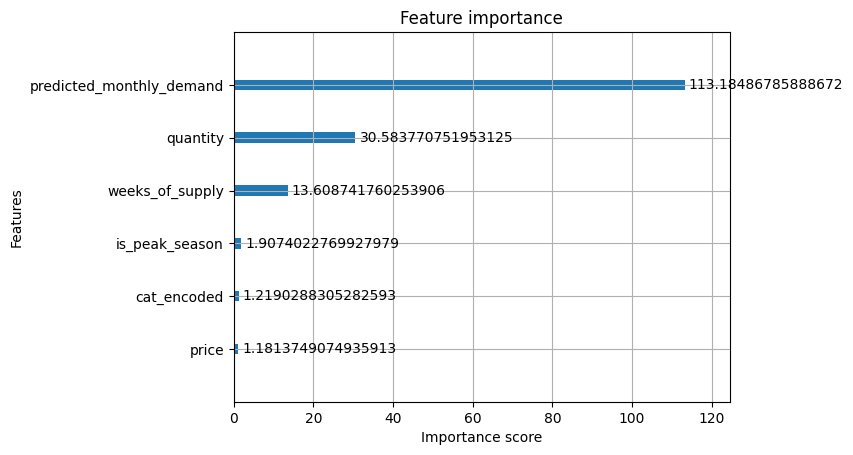

In [34]:
plt.figure(figsize=(10, 6))
plot_importance(
    xgb_clf,
    importance_type='gain',
    max_num_features=15
)
plt.show()

**Deploy best model**

In [293]:
joblib.dump(xgb_clf, "stock_level_classification_model.pkl")
print("✅ Model saved as stock_level_classification_model.pkl")

✅ Model saved as stock_level_classification_model.pkl
